In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("/workspaces/Loan-underwriting/data/raw/Customer_Data.csv")
df.head()

,LAN,Customer ID,Customer Name,Age,State,District,Manufacturer,Vehicle_Model,Existing Customer,Loan amount requested,Loan_tenure(years),Cibil Score,Obligation,Land acres,Crop,Other_documented_income,DPD,Status
0,4,FE4,Monika Gupta,39,Karnataka,Mysuru,KOMA,KX00003,Yes,448588,3,747,87666,2,Rice,498178,0.0,Disbursed
1,5,FE5,Priya Wadwa,33,Karnataka,Channarayapatna,KOMA,KX00003,No,754946,6,677,89413,2,Maize,330556,0.0,Disbursed
2,6,FE6,Tarang S,59,Maharashtra,Pune,KOMA,KX00003,Yes,895696,4,717,157834,1,Rice,273521,114.0,Disbursed
3,9,FE9,Sita Kumari,25,Madhya Pradesh,Dhulagori,KOMA,KX00003,No,823123,5,678,22817,1,Cotton,578129,38.0,Disbursed
4,10,FE10,Suraj Sharma,47,Gujarat,Ahmedabad,KOMA,KX00003,No,473162,3,621,47059,8,Maize,594447,0.0,Disbursed


In [3]:
#Joining Customer data with Crop Income table 
crop_income_df = pd.read_csv(
    "/workspaces/Loan-underwriting/data/raw/Crop_Income.csv"
)

df = df.merge(
    crop_income_df,
    on=["State", "District", "Crop"],
    how="left"
)

#Joining Customer data with Model cost table 
assetcost_df = pd.read_csv(
    "/workspaces/Loan-underwriting/data/raw/Model_cost.csv"
)

df = df.merge(
    assetcost_df,
    on=["Manufacturer", "Vehicle_Model"],
    how="left"
)
df.head()



,LAN,Customer ID,Customer Name,Age,State,District,Manufacturer,Vehicle_Model,Existing Customer,Loan amount requested,...,Obligation,Land acres,Crop,Other_documented_income,DPD,Status,Productivity(quintal/acre),Rate(Rs/quintal),Approved,Net Dealer Price
0,4,FE4,Monika Gupta,39,Karnataka,Mysuru,KOMA,KX00003,Yes,448588,...,87666,2,Rice,498178,0.0,Disbursed,21,2587,No,788205
1,5,FE5,Priya Wadwa,33,Karnataka,Channarayapatna,KOMA,KX00003,No,754946,...,89413,2,Maize,330556,0.0,Disbursed,12,2001,No,788205
2,6,FE6,Tarang S,59,Maharashtra,Pune,KOMA,KX00003,Yes,895696,...,157834,1,Rice,273521,114.0,Disbursed,20,2547,No,788205
3,9,FE9,Sita Kumari,25,Madhya Pradesh,Dhulagori,KOMA,KX00003,No,823123,...,22817,1,Cotton,578129,38.0,Disbursed,6,7511,No,788205
4,10,FE10,Suraj Sharma,47,Gujarat,Ahmedabad,KOMA,KX00003,No,473162,...,47059,8,Maize,594447,0.0,Disbursed,10,2358,No,788205


In [4]:
df["Crop_Income"] = (df["Land acres"]*df["Productivity(quintal/acre)"]*df["Rate(Rs/quintal)"]*2)


df["Total_Income"] = (df["Crop_Income"]+df["Other_documented_income"])

df["LTV"] = (df["Loan amount requested"]/df["Net Dealer Price"])

df["NFCF"] = (df["Total_Income"]-df["Obligation"])

df["Existing Customer"] = (df["Existing Customer"].map({"Yes": 1, "No": 0}))


df.head()

,LAN,Customer ID,Customer Name,Age,State,District,Manufacturer,Vehicle_Model,Existing Customer,Loan amount requested,...,DPD,Status,Productivity(quintal/acre),Rate(Rs/quintal),Approved,Net Dealer Price,Crop_Income,Total_Income,LTV,NFCF
0,4,FE4,Monika Gupta,39,Karnataka,Mysuru,KOMA,KX00003,1,448588,...,0.0,Disbursed,21,2587,No,788205,217308,715486,0.569126,627820
1,5,FE5,Priya Wadwa,33,Karnataka,Channarayapatna,KOMA,KX00003,0,754946,...,0.0,Disbursed,12,2001,No,788205,96048,426604,0.957804,337191
2,6,FE6,Tarang S,59,Maharashtra,Pune,KOMA,KX00003,1,895696,...,114.0,Disbursed,20,2547,No,788205,101880,375401,1.136374,217567
3,9,FE9,Sita Kumari,25,Madhya Pradesh,Dhulagori,KOMA,KX00003,0,823123,...,38.0,Disbursed,6,7511,No,788205,90132,668261,1.044301,645444
4,10,FE10,Suraj Sharma,47,Gujarat,Ahmedabad,KOMA,KX00003,0,473162,...,0.0,Disbursed,10,2358,No,788205,377280,971727,0.600303,924668


In [5]:
""" segment_features = [
    "Age",
    "Cibil Score",
    "NFCF",
    "Land acres",
    "Loan amount requested",
    "LTV",
    "Existing Customer"
] """

' segment_features = [\n    "Age",\n    "Cibil Score",\n    "NFCF",\n    "Land acres",\n    "Loan amount requested",\n    "LTV",\n    "Existing Customer"\n] '

In [6]:
"""segment_df = df[segment_features].copy()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(segment_df)"""

'segment_df = df[segment_features].copy()\n\nfrom sklearn.preprocessing import StandardScaler\n\nscaler = StandardScaler()\n\nX_scaled = scaler.fit_transform(segment_df)'

In [7]:
#Elbow Method
"""from sklearn.cluster import KMeans

inertia = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,9), inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

#The curve is very steep from 2 → 3 → 4, and then starts becoming more gradual."""

'from sklearn.cluster import KMeans\n\ninertia = []\n\nfor k in range(2, 9):\n    kmeans = KMeans(\n        n_clusters=k,\n        random_state=42,\n        n_init=10\n    )\n\n    kmeans.fit(X_scaled)\n    inertia.append(kmeans.inertia_)\n\nplt.figure(figsize=(8,5))\nplt.plot(range(2,9), inertia, marker=\'o\')\nplt.xlabel("Number of clusters")\nplt.ylabel("Inertia")\nplt.title("Elbow Method")\nplt.show()\n\n#The curve is very steep from 2 → 3 → 4, and then starts becoming more gradual.'

In [8]:
"""#Silhouette Score

from sklearn.metrics import silhouette_score

for k in range(2, 6):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    
    print("Clusters:", k, "Silhouette Score:", round(score, 3))"""

'#Silhouette Score\n\nfrom sklearn.metrics import silhouette_score\n\nfor k in range(2, 6):\n    kmeans = KMeans(\n        n_clusters=k,\n        random_state=42,\n        n_init=10\n    )\n\n    labels = kmeans.fit_predict(X_scaled)\n\n    score = silhouette_score(X_scaled, labels)\n\n    print("Clusters:", k, "Silhouette Score:", round(score, 3))'

In [9]:
"""#Creating 3 Segments

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

segment_df["Segment"] = cluster_labels

segment_df.head()"""

'#Creating 3 Segments\n\nfrom sklearn.cluster import KMeans\n\nkmeans = KMeans(\n    n_clusters=3,\n    random_state=42,\n    n_init=10\n)\n\ncluster_labels = kmeans.fit_predict(X_scaled)\n\nsegment_df["Segment"] = cluster_labels\n\nsegment_df.head()'

In [10]:
"""#Creating segment profile
segment_profile = (
    segment_df
    .groupby("Segment")[segment_features]
    .mean()
    .round(2)
)

display(segment_profile)"""

'#Creating segment profile\nsegment_profile = (\n    segment_df\n    .groupby("Segment")[segment_features]\n    .mean()\n    .round(2)\n)\n\ndisplay(segment_profile)'

In [11]:
"""#Segment size
segment_percentage = (
    segment_df["Segment"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print(segment_percentage.round(2))"""

'#Segment size\nsegment_percentage = (\n    segment_df["Segment"]\n    .value_counts(normalize=True)\n    .sort_index() * 100\n)\n\nprint(segment_percentage.round(2))'

In [12]:
"""#Identifying Key characteristics of each segment
overall_profile = segment_df[segment_features].mean()

segment_comparison = (
    segment_profile / overall_profile * 100
).round(1)

display(segment_comparison)"""

'#Identifying Key characteristics of each segment\noverall_profile = segment_df[segment_features].mean()\n\nsegment_comparison = (\n    segment_profile / overall_profile * 100\n).round(1)\n\ndisplay(segment_comparison)'

In [13]:
"""ax = segment_comparison.plot(
    kind="bar",
    figsize=(13, 6)
)

plt.title("Segment Characteristics Relative to Overall Customer Base")
plt.xlabel("Segment")
plt.ylabel("Percentage of Overall Average (%)")
plt.axhline(100, linewidth=1)
plt.xticks(rotation=0)
plt.legend(
    title="Feature",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()"""

'ax = segment_comparison.plot(\n    kind="bar",\n    figsize=(13, 6)\n)\n\nplt.title("Segment Characteristics Relative to Overall Customer Base")\nplt.xlabel("Segment")\nplt.ylabel("Percentage of Overall Average (%)")\nplt.axhline(100, linewidth=1)\nplt.xticks(rotation=0)\nplt.legend(\n    title="Feature",\n    bbox_to_anchor=(1.05, 1),\n    loc="upper left"\n)\n\nplt.tight_layout()\nplt.show()'

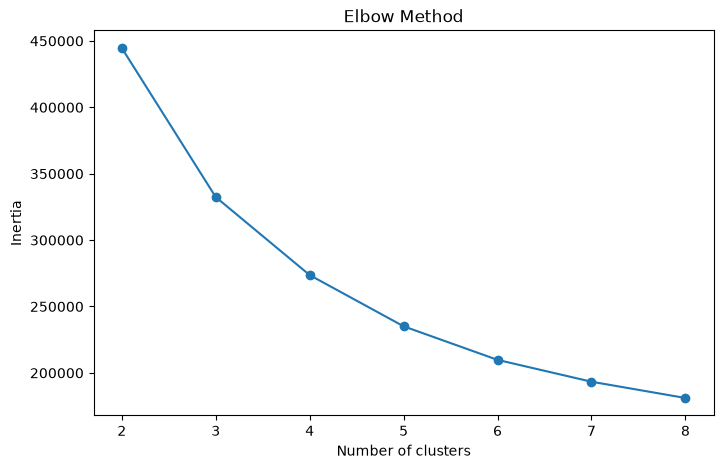

In [14]:
#Removing Age and cibil score as they hold similar values in all segments
segment_features2= [
    "NFCF",
    "Land acres",
    "Loan amount requested",
    "LTV",
    "Existing Customer"
]

segment_df2 = df[segment_features2].copy()

from sklearn.preprocessing import StandardScaler

scaler2 = StandardScaler()

X_scaled2 = scaler2.fit_transform(segment_df2)

#Elbow Method
from sklearn.cluster import KMeans

inertia2 = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled2)
    inertia2.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,9), inertia2, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [15]:
"""#Silhouette Score

from sklearn.metrics import silhouette_score

for k in range(2, 6):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels2 = kmeans.fit_predict(X_scaled2)
    
    score2 = silhouette_score(X_scaled2, labels2)
    
    print("Clusters:", k, "Silhouette Score:", round(score2, 3))"""

'#Silhouette Score\n\nfrom sklearn.metrics import silhouette_score\n\nfor k in range(2, 6):\n    kmeans = KMeans(\n        n_clusters=k,\n        random_state=42,\n        n_init=10\n    )\n\n    labels2 = kmeans.fit_predict(X_scaled2)\n\n    score2 = silhouette_score(X_scaled2, labels2)\n\n    print("Clusters:", k, "Silhouette Score:", round(score2, 3))'

In [16]:
#Creating 5 Segments

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

cluster_labels2 = kmeans.fit_predict(X_scaled2)

segment_df2["Segment"] = cluster_labels2

segment_df2.head()

,NFCF,Land acres,Loan amount requested,LTV,Existing Customer,Segment
0,627820,2,448588,0.569126,1,0
1,337191,2,754946,0.957804,0,4
2,217567,1,895696,1.136374,1,2
3,645444,1,823123,1.044301,0,4
4,924668,8,473162,0.600303,0,3


In [17]:
import joblib

joblib.dump(
    scaler2,
    "../src/models/segmentation_scaler.pkl"
)

joblib.dump(
    kmeans,
    "../src/models/kmeans_model.pkl"
)

['../src/models/kmeans_model.pkl']

In [18]:
import os

print(os.path.exists("../src/models/segmentation_scaler.pkl"))
print(os.path.exists("../src/models/kmeans_model.pkl"))

True
True


In [19]:
#Creating segment profile
segment_profile2 = (
    segment_df2
    .groupby("Segment")[segment_features2]
    .mean()
    .round(2)
)

display(segment_profile2)

,NFCF,Land acres,Loan amount requested,LTV,Existing Customer
Segment,,,,,
0,453009.32,2.03,539799.85,0.51,1.00
1,442711.15,1.91,540048.43,0.51,0.00
2,456168.70,2.10,823686.02,0.78,1.00
3,959434.98,6.67,651711.07,0.61,0.34
4,455072.42,2.04,817120.31,0.77,0.00


In [20]:
segment_percentage2 = (
    segment_df2["Segment"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print(segment_percentage2.round(2))

Segment
0    18.26
1    27.68
2    14.53
3    17.85
4    21.69
Name: proportion, dtype: float64


In [21]:
#Identifying Key characteristics of each segment
overall_profile2 = segment_df2[segment_features2].mean()

segment_comparison2 = (
    segment_profile2 / overall_profile2 * 100
).round(1)

display(segment_comparison2)

,NFCF,Land acres,Loan amount requested,LTV,Existing Customer
Segment,,,,,
0,83.7,71.6,81.6,81.7,257.7
1,81.8,67.3,81.7,81.7,0.0
2,84.2,74.0,124.6,125.0,257.7
3,177.2,235.1,98.6,97.7,87.6
4,84.0,71.9,123.6,123.4,0.0


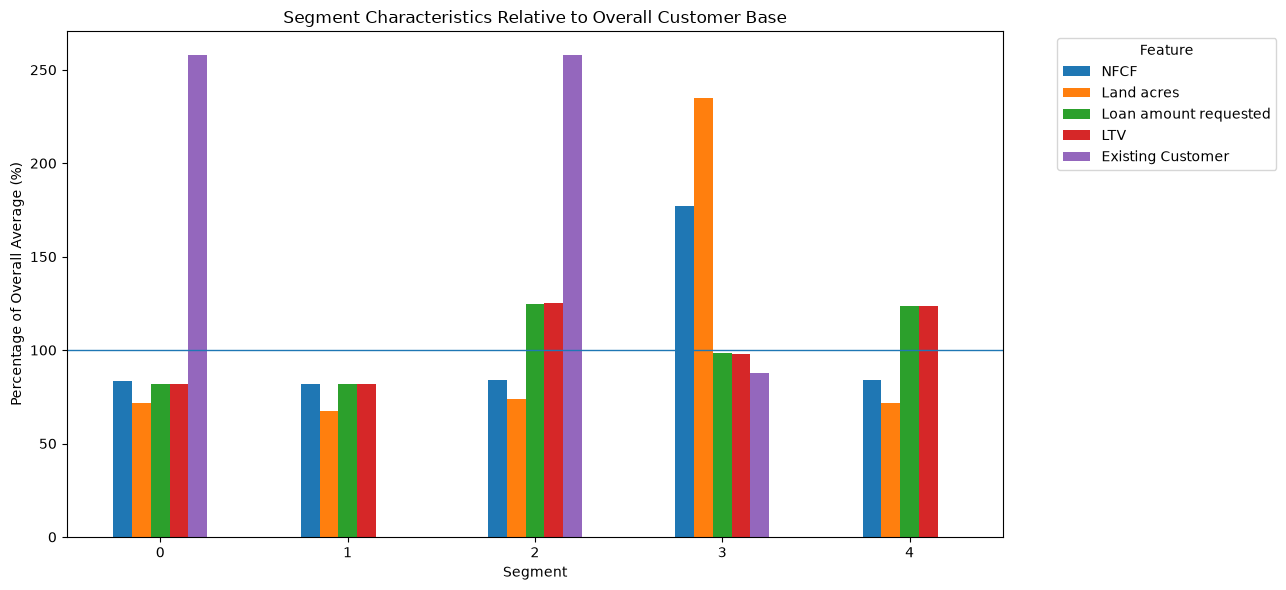

In [22]:
ax = segment_comparison2.plot(
    kind="bar",
    figsize=(13, 6)
)

plt.title("Segment Characteristics Relative to Overall Customer Base")
plt.xlabel("Segment")
plt.ylabel("Percentage of Overall Average (%)")
plt.axhline(100, linewidth=1)
plt.xticks(rotation=0)
plt.legend(
    title="Feature",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [23]:
#Default risk analysis
df["Default"] = (df["DPD"] > 60).astype(int)
df["Segment"] = cluster_labels2
processed_df = df[df["Status"] != "Rejected"].copy()
print(processed_df[["LAN","Segment","Default"]].head(5))



   LAN  Segment  Default
0    4        0        0
1    5        4        0
2    6        2        1
3    9        4        0
4   10        3        0


In [24]:
#Analyzing default drivers in each segment: NFCF, Loan amount, Existing customer, LTV, Land, Age, Cibil.

segment_names = {
    0: "Existing customer- Low Exposure",
    1: "New customer- Low Exposure",
    2: "Existing customer - High Exposure",
    3: "Strong Financial Profile",
    4: "New customer- High Exposure"
}

processed_df["Segment_Name"] = processed_df["Segment"].map(segment_names)

summary = processed_df.groupby("Segment_Name").agg(
    Customer_count=("LAN", "count"),
    Avg_Age=("Age", "mean"),
    Avg_CIBIL=("Cibil Score", "mean"),
    Avg_Land=("Land acres", "mean"),
    Avg_NFCF=("NFCF", "mean"),
    Existing_Customer=("Existing Customer", "mean"),
    Avg_Loan_Amount=("Loan amount requested", "mean"),
    Avg_LTV=("LTV", "mean"),
    Default_Count=("Default", "sum"),
    Default_Rate=("Default", "mean"),
   )

summary["Existing_Customer"] *= 100
summary["Default_Rate"] *= 100

# Rank segments by Default rate
summary["Risk_Rank"] = (summary["Default_Rate"].rank(method="dense", ascending=True).astype(int))

# Risk level
risk_mapping = {
    1: "Very Low",
    2: "Low",
    3: "Moderate",
    4: "High",
    5: "Very High"
}

summary["Risk_Level"] = (summary["Risk_Rank"].map(risk_mapping))

display(summary.round(1))

,Customer_count,Avg_Age,Avg_CIBIL,Avg_Land,Avg_NFCF,Existing_Customer,Avg_Loan_Amount,Avg_LTV,Default_Count,Default_Rate,Risk_Rank,Risk_Level
Segment_Name,,,,,,,,,,,,
Existing customer - High Exposure,16741,39.4,675.7,2.1,462987.3,100.0,823684.2,0.8,644,3.8,4,High
Existing customer- Low Exposure,20398,39.5,675.9,2.0,465015.4,100.0,539594.3,0.5,145,0.7,2,Low
New customer- High Exposure,24695,38.5,675.4,2.0,463488.4,0.0,816879.6,0.8,2470,10.0,5,Very High
New customer- Low Exposure,30147,38.5,675.3,1.9,457608.8,0.0,540313.1,0.5,645,2.1,3,Moderate
Strong Financial Profile,20992,38.5,676.0,6.7,959053.5,33.9,652244.4,0.6,0,0.0,1,Very Low


In [25]:
processed_df.to_csv(
    "../data/processed/processed_data.csv",
    index=False
)

In [26]:
#Chi-square test
from scipy.stats import chi2_contingency

table = pd.crosstab(
    processed_df["Segment"],
    processed_df["Default"]
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 4548.307737171588
P-value: 0.0


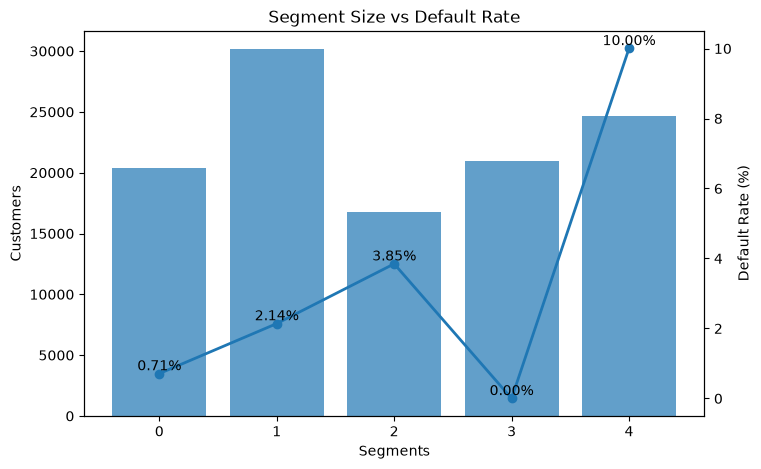

In [27]:
size = processed_df["Segment"].value_counts().sort_index()
rate = processed_df.groupby("Segment")["Default"].mean() * 100

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.bar(size.index, size.values, alpha=0.7)
ax1.set_ylabel("Customers")
ax1.set_xlabel("Segments")

ax2 = ax1.twinx()
ax2.plot(rate.index, rate.values, marker="o", linewidth=2)
ax2.set_ylabel("Default Rate (%)")

for x, y in zip(rate.index, rate):
    ax2.text(x, y, f"{y:.2f}%", ha="center", va="bottom")

plt.title("Segment Size vs Default Rate")
plt.show()

In [29]:
# Predict customer segmentation
new_customer = pd.DataFrame({
        "NFCF": [452934],
        "Land acres": [2],
        "Loan amount requested": [839966],
        "LTV": [0.60],
        "Existing Customer":[1]
    })
    
#  Transform new customer using same scaler
new_customer_scaled = scaler2.transform(new_customer)
    
# Predict segment
new_segment = kmeans.predict(new_customer_scaled)[0]
print("Assigned Segment:", new_segment)

Assigned Segment: 2


In [30]:
segment_profile2 = (
    segment_df2
    .groupby("Segment")[segment_features2]
    .mean()
    .round(2)
)

display(segment_profile2)

,NFCF,Land acres,Loan amount requested,LTV,Existing Customer
Segment,,,,,
0,453009.32,2.03,539799.85,0.51,1.00
1,442711.15,1.91,540048.43,0.51,0.00
2,456168.70,2.10,823686.02,0.78,1.00
3,959434.98,6.67,651711.07,0.61,0.34
4,455072.42,2.04,817120.31,0.77,0.00
